In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import pandas as pd

# Step 1: Load the CSV, skipping the bad first row
df = pd.read_csv(r"/content/lol.csv", skiprows=1)

# Step 2: Use the first real data row as header
df.columns = df.iloc[0]
df = df[1:].copy()

# Step 3: Rename the first column to 'Date'
df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

# Step 4: Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Step 5: Melt to long format
df_long = df.melt(id_vars='Date', var_name='Index', value_name='Close')

# Step 6: Convert 'Close' values to numeric
df_long['Close'] = pd.to_numeric(df_long['Close'], errors='coerce')

# Step 7: Pivot to wide format
df_pivot = df_long.pivot_table(index='Date', columns='Index', values='Close')

# Step 8: Replace columns with actual ticker symbols
tickers = [
    "MMM", "AOS", "ABT", "ACN", "ADBE", "AAP", "AMD", "AES", "AFL", "A", "APD", "AKAM", "ALK", "ALB",
    "ARE", "ALGN", "LNT", "ALL", "GOOGL", "GOOG", "MO", "AMZN", "AEE", "AEP", "AXP", "AIG", "AMT",
    "AME", "AMGN", "APH", "ADI", "ANSS", "AON", "APA", "AIV", "AAPL", "AMAT", "ADM", "AJG", "AIZ",
    "T", "ATO", "ADSK", "ADP", "AZO", "AVB", "AVY", "BKR", "BAC", "BAX", "BDX", "BBY", "BIO", "BIIB",
    "BLK", "BA", "BKNG", "BWA", "BXP", "BSX", "BMY"
]
df_pivot.columns.name = None
df_pivot.columns = tickers

# Step 9: Save to CSV
df_pivot.to_csv('final_closing_prices_pivot.csv')

print("✅ Pivot table saved to 'final_closing_prices_pivot.csv'")


✅ Pivot table saved to 'final_closing_prices_pivot.csv'


In [3]:
df_pivot.head()

,MMM,AOS,ABT,ACN,ADBE,AAP,AMD,AES,AFL,A,...,BBY,BIO,BIIB,BLK,BA,BKNG,BWA,BXP,BSX,BMY
Date,,,,,,,,,,,,,,,,,,,,,
2005-06-30,1.106295,1.482854,1.6545,2.191672,3.217445,4.309952,4.557948,6.830993,6.688256,7.282998,...,36.640156,38.321003,40.095772,41.807968,46.607578,47.286430,50.120579,59.209999,92.459999,705.422852
2005-07-01,1.096977,1.487203,1.6455,2.224952,3.255992,4.342618,4.584031,6.911077,6.679263,7.211196,...,37.264515,38.294907,40.125549,42.084553,45.675442,48.969990,50.587811,59.000000,93.190002,711.614807
2005-07-05,1.141458,1.489378,1.7040,2.318797,3.252378,4.373468,4.585439,6.942623,6.703994,7.321622,...,37.230465,38.947063,40.294266,43.225525,46.198002,50.748711,50.961617,58.849998,95.040001,722.299988
2005-07-06,1.123726,1.482492,1.7030,2.348803,3.240333,4.361951,4.555127,6.855262,6.699497,7.217881,...,36.555000,38.660126,40.552296,43.979267,45.400032,50.097252,52.238777,58.000000,95.099998,718.049927
2005-07-07,1.130940,1.493726,1.6980,2.381539,3.194558,4.315762,4.525521,6.833421,6.645540,7.317414,...,36.259819,39.103596,40.542374,46.281940,46.028530,50.960979,51.453781,58.480000,95.739998,719.628418


In [4]:
#Calculation of the Log Returns
df_returns = (df_pivot.apply(lambda x: np.log(x) - np.log(x.shift(1)))).iloc[1:]
df_returns.head()

,MMM,AOS,ABT,ACN,ADBE,AAP,AMD,AES,AFL,A,...,BBY,BIO,BIIB,BLK,BA,BKNG,BWA,BXP,BSX,BMY
Date,,,,,,,,,,,,,,,,,,,,,
2005-07-01,-0.008458,0.002928,-0.005455,0.015071,0.011909,0.007551,0.005706,0.011655,-0.001346,-0.009908,...,0.016897,-0.000681,0.000742,0.006594,-0.020202,0.034984,0.009279,-0.003553,0.007864,0.008739
2005-07-05,0.039748,0.001462,0.034934,0.041313,-0.001110,0.007079,0.000307,0.004554,0.003696,0.015197,...,-0.000914,0.016886,0.004196,0.026750,0.011376,0.035679,0.007362,-0.002546,0.019657,0.014904
2005-07-06,-0.015657,-0.004634,-0.000587,0.012857,-0.003710,-0.002637,-0.006632,-0.012663,-0.000671,-0.014270,...,-0.018309,-0.007395,0.006383,0.017287,-0.017424,-0.012920,0.024752,-0.014549,0.000631,-0.005901
2005-07-07,0.006399,0.007549,-0.002940,0.013841,-0.014227,-0.010645,-0.006521,-0.003191,-0.008086,0.013696,...,-0.008108,0.011406,-0.000245,0.051034,0.013749,0.017094,-0.015141,0.008242,0.006707,0.002196
2005-07-08,0.016341,0.010858,0.022708,0.017037,0.024950,0.008950,0.010382,0.014105,0.033924,0.002332,...,0.006087,0.013912,0.022989,0.032342,-0.001689,-0.003453,-0.005342,0.021317,0.012043,0.013074


In [5]:
#Calculation of Moving Average for Stock Price
def dailyMovingAverage(df_pivot, moving_avg_period):
  dates = df_pivot.index[moving_avg_period:] #Storing dates of the required dates
  stocks = df_pivot.columns #Storing stock names
  moving_avg = []

  for i in range(df_pivot.shape[0]-moving_avg_period):
    mean = df_pivot.iloc[i:i+moving_avg_period,:].mean()
    moving_avg.append(mean)

  return pd.DataFrame(data = moving_avg, index = dates, columns = stocks)

In [6]:
movingAverage = dailyMovingAverage(df_pivot, 252)

In [7]:
movingAverage.head()

,MMM,AOS,ABT,ACN,ADBE,AAP,AMD,AES,AFL,A,...,BBY,BIO,BIIB,BLK,BA,BKNG,BWA,BXP,BSX,BMY
Date,,,,,,,,,,,,,,,,,,,,,
2006-06-30,1.823509,1.556116,2.032308,2.568457,4.638988,4.786593,5.153989,7.504278,7.617841,9.033433,...,34.911522,44.796329,47.587070,51.846964,51.557416,50.184083,71.210728,61.212897,93.008691,779.600524
2006-07-03,1.825949,1.556863,2.033417,2.571907,4.648784,4.791034,5.157361,7.511483,7.626468,9.045732,...,34.864070,44.833904,47.652633,51.860053,51.605507,50.195795,71.360208,61.235635,92.991786,779.673398
2006-07-05,1.828507,1.557783,2.034548,2.575413,4.658583,4.795376,5.160816,7.518939,7.634818,9.058696,...,34.816073,44.872309,47.720922,51.873581,51.655562,50.202492,71.511488,61.261627,92.975040,779.746994
2006-07-06,1.830776,1.558784,2.035149,2.578148,4.667833,4.799572,5.164049,7.526151,7.643436,9.071051,...,34.768313,44.910735,47.788927,51.881758,51.700327,50.201838,71.657254,61.291191,92.944246,779.767001
2006-07-07,1.832968,1.559830,2.035692,2.580736,4.677076,4.803972,5.168698,7.533379,7.651233,9.083988,...,34.724792,44.951176,47.857634,51.888179,51.750081,50.203857,71.801607,61.323572,92.909802,779.809710


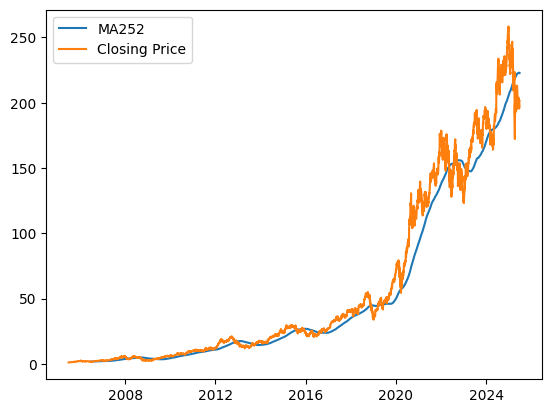

In [8]:
plt.plot(movingAverage.iloc[:,0], label = 'MA252')
plt.plot(df_pivot.iloc[:,0], label = 'Closing Price')
plt.legend()
plt.show()

In [9]:
movingAverage.to_csv('MovingAverage.csv')

In [16]:
raw_df = pd.read_csv(r"/content/stock_new.csv")

/tmp/ipython-input-16-747429196.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262

In [17]:
raw_df.head()

,Unnamed: 0,MMM,MMM.1,MMM.2,MMM.3,MMM.4,MMM.5,AOS,AOS.1,AOS.2,...,BSX.2,BSX.3,BSX.4,BSX.5,BMY,BMY.1,BMY.2,BMY.3,BMY.4,BMY.5
0,Date,Open,High,Low,Close,Volume,Adjusted,Open,High,Low,...,Low,Close,Volume,Adjusted,Open,High,Low,Close,Volume,Adjusted
1,29-06-2005,64.43979645,64.44815826,63.52006531,63.57859421,2661220,35.24580765,4.375,4.440000057,4.373332977,...,27.45000076,27.48999977,3296500,27.48999977,25.25,25.42000008,25.17000008,25.20999908,5392900,12.03044701
2,30-06-2005,61.87290955,62.33277512,60.40969849,60.45150375,17649252,33.51224518,4.456666946,4.480000019,4.429999828,...,26.95999908,27,3852500,27,25.10000038,25.20999908,24.90999985,24.97999954,6283200,11.9206934
3,01-07-2005,60.45986557,61.13712311,59.38963318,61.03678894,10603736,33.83669281,4.454999924,4.518332958,4.453332901,...,26.79999924,26.88999939,3929300,26.88999939,25.28000069,25.36000061,24.98999977,25.20000076,4038900,12.02567673
4,05-07-2005,61.07023239,61.76421356,61.03678894,61.55518341,4783163,34.1240921,4.471666813,4.508333206,4.443333149,...,28.29999924,28.60000038,9692000,28.60000038,25.23999977,25.28000069,25.04000092,25.27000046,5126900,12.05908394


In [18]:
import pandas as pd

# 2) If “Unnamed: 0” exists, rename it to “Date”
if "Unnamed: 0" in raw_df.columns:
    raw_df = raw_df.rename(columns={"Unnamed: 0": "Date"})

# 3) Drop any rows where the “Date” value is not a real date
#    This will remove the spurious header or any bad lines.
raw_df = raw_df[pd.to_datetime(raw_df["Date"], errors="coerce", dayfirst=True).notna()]

# 4) Now safely convert and set as index
raw_df["Date"] = pd.to_datetime(raw_df["Date"], dayfirst=True)
raw_df = raw_df.set_index("Date")

# 5) Define the six raw‐data metrics in order
metrics = ["Open", "High", "Low", "Close", "Volume", "Adjusted"]

# 6) Discover all tickers (prefix before any “.1”, “.2”, …)
tickers = sorted({col.split(".")[0] for col in raw_df.columns})

# 7) Build (ticker, metric) tuples only for existing columns
tuples = []
for t in tickers:
    for i, m in enumerate(metrics):
        raw_col = t if i == 0 else f"{t}.{i}"
        if raw_col in raw_df.columns:
            tuples.append((t, m))

# 8) Assign the MultiIndex
raw_df.columns = pd.MultiIndex.from_tuples(tuples, names=["Ticker", "Metric"])

# 9) Pick only the five you want, in the exact order Adjusted→High→Low→Open→Volume
desired = ["Adjusted", "High", "Low", "Open", "Volume"]
new_cols = [(t, m) for t in tickers for m in desired if (t, m) in raw_df.columns]
df_new = raw_df.loc[:, new_cols]
df_new.columns = pd.MultiIndex.from_tuples(new_cols, names=["Ticker", "Metric"])

# 10) Show the head
df_new.head()


/tmp/ipython-input-18-3485767511.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_df = raw_df[pd.to_datetime(raw_df["Date"], errors="coerce", dayfirst=True).notna()]


Ticker                A                                                   \
Metric         Adjusted         High          Low         Open    Volume   
Date                                                                       
2005-06-29  35.24580765  64.44815826  63.52006531  64.43979645   2661220   
2005-06-30  33.51224518  62.33277512  60.40969849  61.87290955  17649252   
2005-07-01  33.83669281  61.13712311  59.38963318  60.45986557  10603736   
2005-07-05   34.1240921  61.76421356  61.03678894  61.07023239   4783163   
2005-07-06  33.75790787  61.56354523  60.89464951  61.56354523   4489306   

Ticker              AAP                                                  ...  \
Metric         Adjusted         High          Low         Open   Volume  ...   
Date                                                                     ...   
2005-06-29  3.206603289  4.440000057  4.373332977        4.375  1505400  ...   
2005-06-30  3.217444181  4.480000019  4.429999828  4.456666946   756600  ...   
2005-07-01  3.255992413  4.518332958  4.453332901  4.454999924   984000  ...   
2005-07-05  3.252377987  4.508333206  4.443333149  4.471666813   865200  ...   
2005-07-06  3.240332127   4.53000021  4.458333015          4.5   587400  ...   

Ticker               MO                                                  \
Metric         Adjusted         High          Low         Open   Volume   
Date                                                                      
2005-06-29  27.48999977  27.78000069  27.45000076  27.70999908  3296500   
2005-06-30           27  27.47999954  26.95999908  27.45999908  3852500   
2005-07-01  26.88999939  27.10000038  26.79999924  26.98999977  3929300   
2005-07-05  28.60000038  29.04000092  28.29999924        28.75  9692000   
2005-07-06           28  28.68000031  27.89999962  28.62000084  5960400   

Ticker                T                                                  
Metric         Adjusted         High          Low         Open   Volume  
Date                                                                     
2005-06-29  12.03044701  25.42000008  25.17000008        25.25  5392900  
2005-06-30   11.9206934  25.20999908  24.90999985  25.10000038  6283200  
2005-07-01  12.02567673  25.36000061  24.98999977  25.28000069  4038900  
2005-07-05  12.05908394  25.28000069  25.04000092  25.23999977  5126900  
2005-07-06  11.87297916        25.25  24.87999916  25.20000076  3806600  

[5 rows x 305 columns]

In [19]:
raw_df = raw_df.to_numpy()
raw_df.shape

(5027, 366)

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

#Scaling the data
raw_df_scaled = MinMaxScaler().fit_transform(raw_df)

#Performing PCA ~ Reducing Dimensionality
PCA = PCA(n_components=366)
PCA_df = PCA.fit_transform(raw_df_scaled)

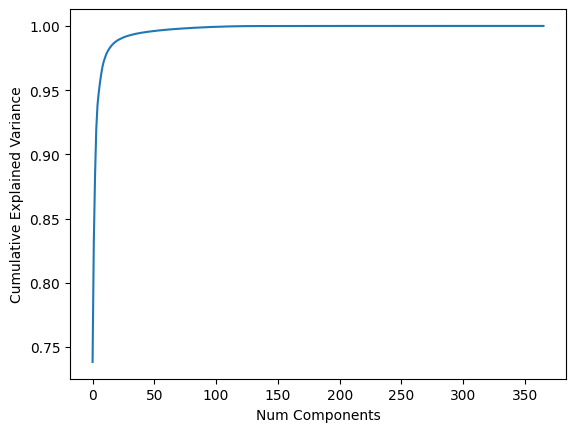

In [21]:
plt.plot(np.cumsum(PCA.explained_variance_ratio_))
plt.xlabel('Num Components')
plt.ylabel('Cumulative Explained Variance');

In [22]:
dates = df_pivot.index
stocks = df_pivot.columns
PC_labs = []
for i in range(PCA_df.shape[1]):
  lab = "PC" + str(i+1)
  PC_labs.append(lab)

In [23]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

#Using the full features dataset, the closing prices; we are able to fit a line over a specified time period
def predict_prices(raw_df, close, time, lookback, forward, stock_num):

  #PCA
  pca1 = PCA(n_components = 10)
  pca2 = PCA(n_components = 10)


  #Training data = t - forward - lookback
  X_train = raw_df[time-forward-lookback:time-forward,:]
  X_train = MinMaxScaler().fit_transform(X_train)
  X_train = pca1.fit_transform(X_train)
  y_train = close.iloc[time-forward+1:time+1,stock_num]

  #Testing = t - lookback
  X_test = raw_df[time-lookback:time,:]
  X_test = MinMaxScaler().fit_transform(X_test)
  X_test = pca2.fit_transform(X_test)
  y_test = close.iloc[time+1 : time+forward+1, stock_num]

  LR = LinearRegression()
  LR.fit(X_train, y_train)
  predicted = LR.predict(X_test)

  return predicted, y_test

In [24]:
#This function creates the entire table of features
def construct_prediction_tab(full_features_df,closing_prices_df):
  predictions = []
  actuals = []

  for stocks in range(closing_prices_df.shape[1]):
    stock_predictions = []
    stock_actuals = []

    for dates in range(60, df_pivot.shape[0], 30):
      pred, act = predict_prices(full_features_df, closing_prices_df, dates, 30, 30, stocks)
      stock_predictions.append(pred)
      stock_actuals.append(act)

    import numpy as np
    stock_predictions = np.concatenate(stock_predictions)
    stock_actuals = np.concatenate(stock_actuals)

    predictions.append(stock_predictions)
    actuals.append(stock_actuals)

  return predictions, actuals

In [25]:
pred, act = construct_prediction_tab(raw_df, df_pivot)

In [26]:
# Need to get rid of 60 days for initial prediction window
final_actuals = pd.DataFrame(data = act, index=stocks, columns = dates[61:]).transpose()
final_preds = pd.DataFrame(data = pred, index = stocks).transpose() #Trimming because it predicts extra dates into future

In [27]:
final_preds = final_preds.iloc[:4965,:]
final_preds.index = dates[61:]

In [28]:
final_actuals.head()

,MMM,AOS,ABT,ACN,ADBE,AAP,AMD,AES,AFL,A,...,BBY,BIO,BIIB,BLK,BA,BKNG,BWA,BXP,BSX,BMY
Date,,,,,,,,,,,,,,,,,,,,,
2005-09-27,1.606096,1.419603,2.1580,2.173578,3.277568,4.367495,5.238078,7.126652,6.755702,7.772988,...,32.899502,42.781765,41.753178,55.299076,47.171650,55.221493,53.409866,54.410000,87.760002,739.590637
2005-09-28,1.535168,1.407464,2.1685,2.162112,3.316342,4.415527,5.236653,7.104610,6.661278,7.576398,...,32.192791,42.599174,41.549706,55.195347,47.639477,55.866394,53.991360,54.490002,86.739998,741.903687
2005-09-29,1.573036,1.413717,2.2395,2.203061,3.367233,4.382272,5.249483,7.178082,6.418478,7.666027,...,32.575943,43.483051,42.255398,55.160789,47.689098,56.181538,55.185593,55.139999,86.849998,757.849121
2005-09-30,1.611205,1.426593,2.2650,2.202516,3.453259,4.428459,5.253761,7.133997,6.533133,7.835381,...,32.933548,43.504086,42.891014,55.091644,48.164005,55.126205,55.410706,54.990002,83.250000,754.197144
2005-10-03,1.636150,1.430272,2.3005,2.199239,3.539290,4.426612,5.285835,7.302981,6.598330,7.890348,...,33.206013,43.930233,43.346428,55.057041,47.589855,55.074936,55.723328,54.750000,82.580002,749.085083


In [29]:
final_preds.head()

,MMM,AOS,ABT,ACN,ADBE,AAP,AMD,AES,AFL,A,...,BBY,BIO,BIIB,BLK,BA,BKNG,BWA,BXP,BSX,BMY
Date,,,,,,,,,,,,,,,,,,,,,
2005-09-27,1.523799,1.513536,2.147376,2.287218,3.262801,4.444817,5.161467,7.476965,7.138088,7.464604,...,33.206718,45.701573,42.959256,58.185451,44.735813,52.010268,52.604755,55.852789,93.731424,733.886870
2005-09-28,1.538528,1.507094,2.153659,2.279865,3.271555,4.457024,5.140410,7.464884,7.080399,7.468596,...,33.435111,45.626935,43.064915,58.505293,44.904402,52.740146,52.583553,55.656891,94.108433,736.282681
2005-09-29,1.541868,1.503016,2.157660,2.271161,3.320503,4.458782,5.114081,7.478326,7.122704,7.464566,...,33.568743,45.491677,43.148049,58.442933,45.470359,53.143544,52.500555,55.640313,94.323027,737.890254
2005-09-30,1.524904,1.479804,2.139878,2.216251,3.358565,4.434751,5.101068,7.437836,6.996723,7.502747,...,33.512175,45.084049,42.940099,58.157898,45.698222,53.576798,52.206444,54.825119,92.570949,733.609225
2005-10-03,1.504875,1.451510,2.124695,2.190556,3.369923,4.391602,5.099815,7.394138,6.945937,7.560000,...,33.444170,44.326744,42.418711,57.113954,45.758839,53.263991,52.156335,54.789731,91.460606,726.979767


In [30]:
final_actuals.to_csv('LR_Actual_Prices.csv')
final_preds.to_csv('LR_Predicted_Prices.csv')

In [31]:
# Three different Prediction Windows
p1 , t1 = predict_prices(raw_df, df_pivot, 60, 30, 30, 5)
p2 , t2 = predict_prices(raw_df, df_pivot, 90, 30, 30, 5)
p3 , t3 = predict_prices(raw_df, df_pivot, 120, 30, 30, 5)

In [32]:
predictions = np.concatenate([p1,p2,p3])
actuals = np.concatenate((t1,t2,t3))

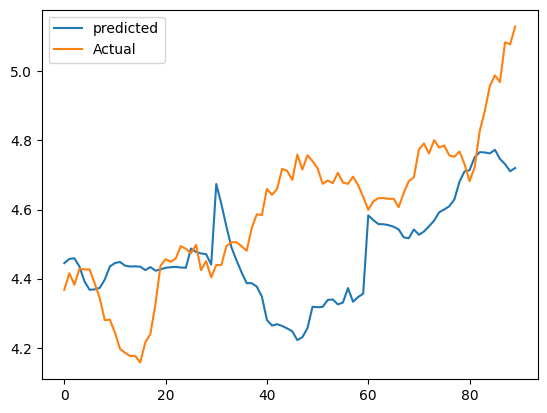

In [33]:
#This is a plt for the first 90 days of predictions for the first stock
plt.plot(predictions, label = 'predicted')
plt.plot(actuals, label = 'Actual')
plt.legend()
plt.show()

In [34]:
stock_predictions = []
stock_actuals = []

for i in range(60,df_pivot.shape[0], 30):
  pred, act = predict_prices(raw_df, df_pivot, i, 30, 30, 5)
  stock_predictions.append(pred)
  stock_actuals.append(act)

In [35]:
stock_predictions = np.concatenate(stock_predictions)
stock_actuals = np.concatenate(stock_actuals)

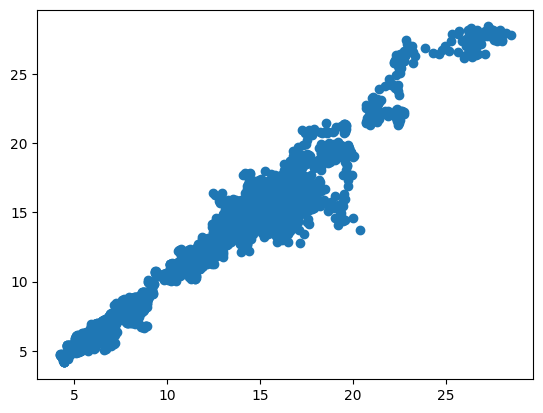

In [36]:
# Q-Q plot for predictions vs actuals
plt.scatter(x = stock_predictions[:4965], y = stock_actuals)

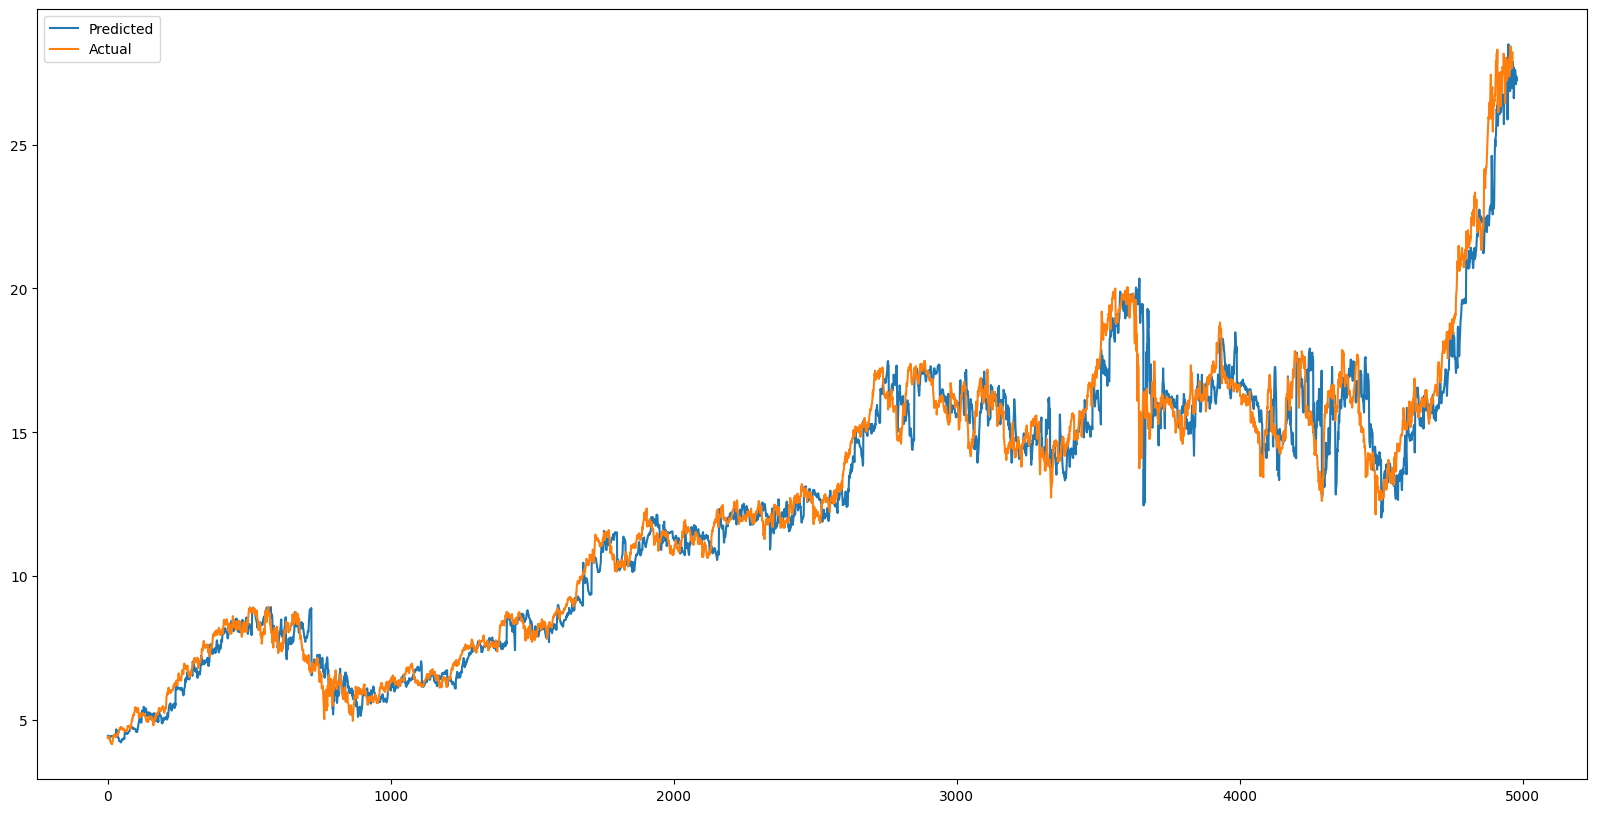

In [37]:
#Full Prediction vs Actuals for the same stock
plt.figure(figsize=(20,10))
plt.plot(stock_predictions, label = 'Predicted')
plt.plot(stock_actuals, label = 'Actual')
plt.legend()

In [38]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(final_actuals, final_preds)

7.975647179493824